# Notebook 6 – Real-World AI Demos and Learning Roadmap

In this final notebook, we will:

- Connect what you learned (tabular + NNs) to **real-world AI applications**.
- See how TensorFlow is used for **images, text, and time series**.
- (Optionally) run a tiny **pretrained image classification** demo.
- Build a **roadmap** for what to learn after this bootcamp.

This notebook is more about ideas, links, and next steps than heavy coding.


## 1. Where TensorFlow is used in the real world

TensorFlow is used in many domains, for example:

- **Computer Vision**
  - Image classification (cats vs dogs, defect detection).
  - Object detection (self-driving cars, CCTV analytics).
  - Medical imaging (X-ray, MRI analysis).

- **Natural Language Processing (NLP)**
  - Sentiment analysis (positive/negative reviews).
  - Text classification (spam detection, topic tagging).
  - Translation, summarization, chatbots.

- **Time Series and Forecasting**
  - Stock price prediction.
  - Demand forecasting.
  - Sensor anomaly detection.

- **Recommendation Systems**
  - Personalized content (YouTube, Netflix).
  - Product recommendations (e-commerce).

The same core ideas apply:

> Data → preprocessing → model → training → evaluation → deployment


## 2. High-quality official TensorFlow tutorials

If you want to go beyond this bootcamp, these official tutorials are great starting points:

- **Computer vision (images)**
  - Image classification (basic): https://www.tensorflow.org/tutorials/images/classification
  - Convolutional Neural Networks (CNNs): https://www.tensorflow.org/tutorials/images/cnn
  - Transfer learning with pre-trained models: https://www.tensorflow.org/tutorials/images/transfer_learning_with_hub

- **Basic deep learning with Keras**
  - Classify clothing images (Fashion MNIST): https://www.tensorflow.org/tutorials/keras/classification

- **Structured (tabular) data**
  - Structured data classification & preprocessing layers: https://www.tensorflow.org/tutorials/structured_data/preprocessing_layers
  - Keras structured data examples: https://keras.io/examples/structured_data/

Use these as:
- Templates you can modify for your own datasets.
- Study material to see “production-style” TensorFlow code.


## 3. Optional demo: Pretrained image classifier in a few lines

To show how powerful pre-trained models are, we will:

- Load a **pretrained image classification model** (e.g., MobileNetV2) from `tf.keras.applications`.
- Download a sample image from the internet.
- Run the model and print the top predicted class.

This is not about training from scratch; it's about **using a model that already knows 1000+ classes** trained on ImageNet.

> You can skip the next 2–3 cells if you just want discussion and no extra code during the event.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


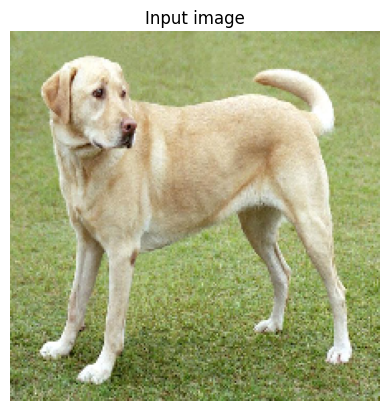

Top predictions:
Labrador_retriever: 46.92%
Eskimo_dog: 5.37%
Ibizan_hound: 2.44%


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Sample image URL from TensorFlow examples (dog photo)
img_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
img_path = "sample_image.jpg"

# Download the image (if not already present)
if not os.path.exists(img_path):
    urllib.request.urlretrieve(img_url, img_path)

# 1) Load the image normally for display (0–255 uint8)
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)  # shape (224, 224, 3), values 0–255

# 2) Preprocess a *copy* for MobileNetV2 (−1..1, etc.)
img_batch = np.expand_dims(img_array.copy(), axis=0)
img_preprocessed = mobilenet_v2.preprocess_input(img_batch)

# Load pretrained MobileNetV2 model + ImageNet weights
model = mobilenet_v2.MobileNetV2(weights="imagenet")

# Predict using the preprocessed image
preds = model.predict(img_preprocessed)

# Decode top-3 predictions
decoded = tf.keras.applications.mobilenet_v2.decode_predictions(preds, top=3)[0]

# Show the *original* image (not preprocessed) so it doesn't look black
plt.imshow(img_array.astype("uint8"))
plt.axis("off")
plt.title("Input image")
plt.show()

print("Top predictions:")
for (_, class_name, prob) in decoded:
    print(f"{class_name}: {prob*100:.2f}%")


### What just happened in the image demo?

In this small demo, we:

1. Loaded a **pre-trained MobileNetV2** model that was trained on ImageNet (1000 everyday object classes).
2. Downloaded a sample dog image from TensorFlow’s example images.
3. Resized and **preprocessed** the image in the exact way MobileNetV2 expects.
4. Ran `model.predict(...)` and decoded the top-3 predicted labels.

Important:

- We used a **preprocessed copy** of the image (`img_preprocessed`) for prediction.
- We displayed the **original** image array (`img_array`) so the image looked normal in the plot.

This shows how you can use powerful pre-trained models in just a few lines, without training from scratch.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


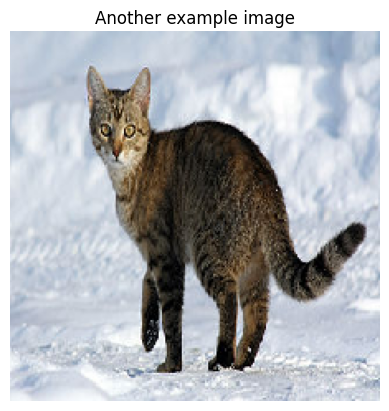

Top predictions:
lynx: 50.27%
Egyptian_cat: 7.39%
tabby: 5.31%
----------------------------------------


In [4]:
def classify_image(img_url: str, title: str = "Input image"):
    img_path = "temp_image.jpg"
    urllib.request.urlretrieve(img_url, img_path)

    # Load for display
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # Preprocess copy for model
    img_batch = np.expand_dims(img_array.copy(), axis=0)
    img_preprocessed = mobilenet_v2.preprocess_input(img_batch)

    # Predict
    preds = model.predict(img_preprocessed)
    decoded = tf.keras.applications.mobilenet_v2.decode_predictions(preds, top=3)[0]

    # Show image
    plt.imshow(img_array.astype("uint8"))
    plt.axis("off")
    plt.title(title)
    plt.show()

    print("Top predictions:")
    for (_, class_name, prob) in decoded:
        print(f"{class_name}: {prob*100:.2f}%")
    print("-" * 40)


# Example: classify a cat image
cat_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg"
classify_image(cat_url, title="Another example image")


## Connecting this demo back to the bootcamp

This image demo is doing the same things you did with tabular data:

1. **Input pipeline**:
   - Load image from disk/URL.
   - Resize and preprocess (like feature engineering).

2. **Model**:
   - A neural network (MobileNetV2) instead of a simple dense network.
   - Uses convolutional layers specialized for images.

3. **Prediction and interpretation**:
   - `model.predict(...)` → probabilities for each class.
   - Decode and print the most likely labels.

The big idea:

> Once you understand the ML workflow on tabular data, you can apply the same pattern to images, text, and many other data types using TensorFlow.
